# Introduction to Machine Learning: Unsupervised Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 2: Principal Component Analysis (PCA)

---

In this lab, you will explore **Principal Component Analysis (PCA)**, one of the most
important dimensionality reduction techniques in machine learning. You will work with
the **Wine dataset**, which contains chemical measurements from 178 wine samples.

You will:
- Understand why standardization is critical before applying PCA
- Fit a PCA model and analyze variance explained by each component
- Use scree plots and cumulative variance to choose the number of components
- Interpret loadings to understand what each principal component represents
- Transform data to principal component space and visualize the results
- Reconstruct data from a reduced number of components

These concepts are fundamental to dimensionality reduction, data visualization,
and preprocessing for downstream machine learning tasks.

## Setup (do not edit)

In [2]:
import pathlib
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("wine.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "wine.csv is missing from the lab directory. Please run the download "
        "script (w2_download_datasets.py) or ask the TA for assistance."
    )

## 1. Load the Dataset *(10 points)*

Load the Wine dataset from `wine.csv` into a pandas DataFrame.

The Wine dataset contains chemical measurements from wines produced by three
different Italian cultivars. Each row represents a wine sample, and each column
represents a chemical property (e.g., alcohol content, malic acid, color intensity).

Store the following in the required variables:
- **`q1_shape`**: A tuple containing the shape of the DataFrame `(n_samples, n_features)`
- **`q1_columns`**: A list of all column names (feature names)
- **`q1_n_features`**: An integer representing the number of features

In [61]:
# Grade Cell: Question 1
#
# Task: Load the Wine dataset and explore its structure
#
# Instructions:
# 1. Read the CSV file using pd.read_csv()
# 2. Store the shape as a tuple in q1_shape
# 3. Store the column names as a list in q1_columns
# 4. Store the number of features (columns) as an integer in q1_n_features

# your code here
# raise NotImplementedError

# Print the CSV format directly
# print('print csv format temp to clone and test locally')
# df0 = pd.read_csv('wine.csv', index_col=0)
# print(df0.to_csv())

df = pd.read_csv('wine.csv', index_col=0)
print(df.keys())
df_index_name = df.index.name
print(f'df_index_name: {df_index_name} | index \n{df.index}')
print(f'observations/samples size: {df.index.size}')
display(df.describe())
display(df.head())

# add index as feature to pass test
# not sure this is correct but i guess its fine to move index
# to feature in unsupervised learning PCA.
df[df_index_name] = df.index

q1_shape = df.shape
q1_rows = list(df.index)
q1_columns = list(df.columns)
q1_n_features = len(q1_columns)
print(f'q1_shape: {q1_shape} | q1_columns: {q1_columns} | q1_n_features: {q1_n_features}')
print(f'rows: {q1_rows}')


# BEGIN HIDDEN TESTS
assert q1_shape == (178, 13), "Expected 178 samples and 13 features."
assert q1_n_features == 13, "Expected 13 features."
assert "alcohol" in q1_columns, "Expected 'alcohol' to be a feature."
assert "proline" in q1_columns, "Expected 'proline' to be a feature."
# END HIDDEN TESTS


print csv format temp to clone and test locally
alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
14.23,1.71,2.43,15.6,127.0,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
13.2,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.4,1050.0
13.16,2.36,2.67,18.6,101.0,2.8,3.24,0.3,2.81,5.68,1.03,3.17,1185.0
14.37,1.95,2.5,16.8,113.0,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480.0
13.24,2.59,2.87,21.0,118.0,2.8,2.69,0.39,1.82,4.32,1.04,2.93,735.0
14.2,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
14.39,1.87,2.45,14.6,96.0,2.5,2.52,0.3,1.98,5.25,1.02,3.58,1290.0
14.06,2.15,2.61,17.6,121.0,2.6,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
14.83,1.64,2.17,14.0,97.0,2.8,2.98,0.29,1.98,5.2,1.08,2.85,1045.0
13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0
14.1,2.16,2.3,18.0,105.0,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510.0
14.12,1.48,2.32,16.8,95.0,2.2,2.43,0.26,1.5

,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,,,,,,,,,,,,
14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


q1_shape: (178, 13) | q1_columns: ['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'alcohol'] | q1_n_features: 13
rows: [14.23, 13.2, 13.16, 14.37, 13.24, 14.2, 14.39, 14.06, 14.83, 13.86, 14.1, 14.12, 13.75, 14.75, 14.38, 13.63, 14.3, 13.83, 14.19, 13.64, 14.06, 12.93, 13.71, 12.85, 13.5, 13.05, 13.39, 13.3, 13.87, 14.02, 13.73, 13.58, 13.68, 13.76, 13.51, 13.48, 13.28, 13.05, 13.07, 14.22, 13.56, 13.41, 13.88, 13.24, 13.05, 14.21, 14.38, 13.9, 14.1, 13.94, 13.05, 13.83, 13.82, 13.77, 13.74, 13.56, 14.22, 13.29, 13.72, 12.37, 12.33, 12.64, 13.67, 12.37, 12.17, 12.37, 13.11, 12.37, 13.34, 12.21, 12.29, 13.86, 13.49, 12.99, 11.96, 11.66, 13.03, 11.84, 12.33, 12.7, 12.0, 12.72, 12.08, 13.05, 11.84, 12.67, 12.16, 11.65, 11.64, 12.08, 12.08, 12.0, 12.69, 12.29, 11.62, 12.47, 11.81, 12.29, 12.37, 12.29, 12.08, 12.6, 12.34, 11.82, 12.51, 12.42,

In [46]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (n_samples, n_features). "
    "Make sure you're using .shape, not .shape[0]."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
assert isinstance(q1_columns, list), (
    "q1_columns must be a list. Use df.columns.tolist() to convert."
)
assert len(q1_columns) == q1_shape[1], (
    "Number of columns in q1_columns should match q1_shape[1]."
)
assert isinstance(q1_n_features, int), (
    "q1_n_features must be an integer."
)
print(f"Dataset shape: {q1_shape}")
print(f"Number of features: {q1_n_features}")
print(f"Features: {q1_columns}")

Dataset shape: (178, 13)
Number of features: 13
Features: ['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'alcohol']


## 2. Compute Summary Statistics *(10 points)*

Before applying PCA, it's important to understand the scale of each feature.
Features with vastly different scales will dominate PCA if we don't standardize.

Compute the **mean**, **standard deviation**, and **range** (max - min) for each feature.

Store the results as:
- **`q2_means`**: A dictionary mapping feature names to their mean values (rounded to 2 decimals)
- **`q2_stds`**: A dictionary mapping feature names to their standard deviation values (rounded to 2 decimals, use `ddof=0`)
- **`q2_max_range_feature`**: The name of the feature with the largest range (string)

In [48]:
# Grade Cell: Question 2
#
# Task: Compute summary statistics for each feature
#
# Instructions:
# 1. Calculate the mean of each column and round to 2 decimals
# 2. Calculate the standard deviation of each column (use ddof=0) and round to 2 decimals
# 3. Calculate the range (max - min) for each column
# 4. Find the feature with the largest range

# your code here
# raise NotImplementedError


# 1. Calculate the mean of each column and round to 2 decimals
# 2. Calculate the standard deviation of each column (use ddof=0) and round to 2 decimals
q2_means = {}
q2_stds = {}
q3_ranges = {}
for c in q1_columns:
    c_vector = df[c]
    c_mean = c_vector.mean()
    c_std = np.std(c_vector, ddof=0)
    q2_means[c] = round(c_mean, 2)
    q2_stds[c] = round(c_std, 2)
    
# 3. Calculate the range (max - min) for each column
    c_range = df[c].max() - df[c].min()
    q3_ranges[c] = round(c_range, 2)
    
print(f'q2_means: \n{q2_means} \nq2_stds: \n{q2_stds} | \nq3_ranges: \n{q3_ranges}')

# 4. Find the feature with the largest range
# q2_max_range_feature: The name of the feature with the largest range (string)
# print(pd.DataFrame(q3_ranges, index=len(q3_ranges)))
q3_ranges_series = pd.Series(q3_ranges)
print(q3_ranges_series)
print(q3_ranges_series.max())
print(q3_ranges_series.idxmax())
q2_max_range_feature = q3_ranges_series.idxmax()


# BEGIN HIDDEN TESTS
# Proline has the largest range (around 1000)
assert q2_max_range_feature == "proline", (
    "Proline should have the largest range (around 1000). "
    "This feature would dominate PCA without standardization."
)
assert abs(q2_means["alcohol"] - 13.0) < 0.1, "Alcohol mean should be ~13.0."
# END HIDDEN TESTS


q2_means: 
{'malic_acid': 2.34, 'ash': 2.37, 'alcalinity_of_ash': 19.49, 'magnesium': 99.74, 'total_phenols': 2.3, 'flavanoids': 2.03, 'nonflavanoid_phenols': 0.36, 'proanthocyanins': 1.59, 'color_intensity': 5.06, 'hue': 0.96, 'od280/od315_of_diluted_wines': 2.61, 'proline': 746.89, 'alcohol': 13.0} 
q2_stds: 
{'malic_acid': 1.11, 'ash': 0.27, 'alcalinity_of_ash': 3.33, 'magnesium': 14.24, 'total_phenols': 0.62, 'flavanoids': 1.0, 'nonflavanoid_phenols': 0.12, 'proanthocyanins': 0.57, 'color_intensity': 2.31, 'hue': 0.23, 'od280/od315_of_diluted_wines': 0.71, 'proline': 314.02, 'alcohol': 0.81} | 
q3_ranges: 
{'malic_acid': 5.06, 'ash': 1.87, 'alcalinity_of_ash': 19.4, 'magnesium': 92.0, 'total_phenols': 2.9, 'flavanoids': 4.74, 'nonflavanoid_phenols': 0.53, 'proanthocyanins': 3.17, 'color_intensity': 11.72, 'hue': 1.23, 'od280/od315_of_diluted_wines': 2.73, 'proline': 1402.0, 'alcohol': 3.8}
malic_acid                         5.06
ash                                1.87
alcalinity_of

In [6]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_means, dict), (
    "q2_means must be a dictionary mapping feature names to mean values."
)
assert isinstance(q2_stds, dict), (
    "q2_stds must be a dictionary mapping feature names to std values."
)
assert len(q2_means) == q1_n_features, (
    f"q2_means should have {q1_n_features} entries, one for each feature."
)
assert len(q2_stds) == q1_n_features, (
    f"q2_stds should have {q1_n_features} entries, one for each feature."
)
assert all(isinstance(v, float) for v in q2_means.values()), (
    "All mean values should be floats. Use round() to ensure this."
)
assert all(v > 0 for v in q2_stds.values()), (
    "Standard deviations must be positive. Check your calculation."
)
assert isinstance(q2_max_range_feature, str), (
    "q2_max_range_feature must be a string (the feature name)."
)
assert q2_max_range_feature in q1_columns, (
    "q2_max_range_feature must be one of the feature names."
)
print(f"Feature means: {q2_means}")
print(f"Feature stds: {q2_stds}")
print(f"Feature with largest range: {q2_max_range_feature}")

Feature means: {'malic_acid': 2.34, 'ash': 2.37, 'alcalinity_of_ash': 19.49, 'magnesium': 99.74, 'total_phenols': 2.3, 'flavanoids': 2.03, 'nonflavanoid_phenols': 0.36, 'proanthocyanins': 1.59, 'color_intensity': 5.06, 'hue': 0.96, 'od280/od315_of_diluted_wines': 2.61, 'proline': 746.89}
Feature stds: {'malic_acid': 1.11, 'ash': 0.27, 'alcalinity_of_ash': 3.33, 'magnesium': 14.24, 'total_phenols': 0.62, 'flavanoids': 1.0, 'nonflavanoid_phenols': 0.12, 'proanthocyanins': 0.57, 'color_intensity': 2.31, 'hue': 0.23, 'od280/od315_of_diluted_wines': 0.71, 'proline': 314.02}
Feature with largest range: proline


## 3. Standardize the Data *(10 points)*

As we saw in Question 2, features have vastly different scales (e.g., proline ranges
from ~280 to ~1680, while hue ranges from ~0.5 to ~1.7). Without standardization,
proline would dominate PCA because it has the largest variance.

Apply **z-score standardization** to the data:
$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

Use `sklearn.preprocessing.StandardScaler` to standardize all features.

Store the results as:
- **`q3_scaled_data`**: A numpy array of the standardized data
- **`q3_scaled_means`**: A numpy array of column means of the scaled data (should all be ~0)
- **`q3_scaled_stds`**: A numpy array of column stds of the scaled data (should all be ~1)

In [50]:
# Grade Cell: Question 3
#
# Task: Standardize the data using StandardScaler
#
# Instructions:
# 1. Create a StandardScaler instance
# 2. Fit and transform the data (df.values or df as input)
# 3. Compute the column means and stds of the scaled data to verify

# your code here
# raise NotImplementedError

# 1. Create a StandardScaler instance
scaler = StandardScaler()
# 2. Fit and transform the data (df.values or df as input)
# q3_scaled_data: A numpy array of the standardized data
q3_scaled_data = scaler.fit_transform(df)
print(f'q3_scaled_data type: {type(q3_scaled_data)} | shape {q3_scaled_data.shape}')
# 3. Compute the column means and stds of the scaled data to verify
# q3_scaled_means: A numpy array of column means of the scaled data (should all be ~0)
q3_scaled_means = q3_scaled_data.mean(axis=0)
# q3_scaled_stds: A numpy array of column stds of the scaled data (should all be ~1)
q3_scaled_stds = q3_scaled_data.std(axis=0)
print(f"scaled Mean: {q3_scaled_means}")
print(f"scaled Std Dev: {q3_scaled_stds}")
print('mean of scaled means and std of scaled data:')
print(np.mean(q3_scaled_data),np.std(q3_scaled_data))

# BEGIN HIDDEN TESTS
# Verify scaling is correct for specific features
assert q3_scaled_data.shape == (178, 13), "Shape should be (178, 13)."
# END HIDDEN TESTS


q3_scaled_data type: <class 'numpy.ndarray'> | shape (178, 13)
scaled Mean: [-1.19754394e-16 -8.37033314e-16 -3.99181312e-17 -3.99181312e-17
  0.00000000e+00 -3.99181312e-16  3.59263181e-16 -1.19754394e-16
  2.49488320e-17  1.99590656e-16  3.19345050e-16 -1.59672525e-16
 -8.38280756e-16]
scaled Std Dev: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
mean of scaled means and std of scaled data:
-1.3817814653934533e-16 1.0


In [8]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(q3_scaled_data, np.ndarray), (
    "q3_scaled_data must be a numpy array."
)
assert q3_scaled_data.shape == q1_shape, (
    f"Scaled data should have same shape as original: {q1_shape}."
)
assert isinstance(q3_scaled_means, np.ndarray), (
    "q3_scaled_means must be a numpy array."
)
assert isinstance(q3_scaled_stds, np.ndarray), (
    "q3_scaled_stds must be a numpy array."
)
# Check that all means are approximately 0
assert np.allclose(q3_scaled_means, 0, atol=0.01), (
    "After standardization, all feature means should be ~0. "
    "Did you use StandardScaler correctly?"
)
# Check that all stds are approximately 1
assert np.allclose(q3_scaled_stds, 1, atol=0.01), (
    "After standardization, all feature stds should be ~1. "
    "Did you use StandardScaler correctly?"
)
print(f"Scaled data shape: {q3_scaled_data.shape}")
print(f"Scaled means (should be ~0): {q3_scaled_means}")
print(f"Scaled stds (should be ~1): {q3_scaled_stds}")

Scaled data shape: (178, 12)
Scaled means (should be ~0): [-1.19754394e-16 -8.37033314e-16 -3.99181312e-17 -3.99181312e-17
  0.00000000e+00 -3.99181312e-16  3.59263181e-16 -1.19754394e-16
  2.49488320e-17  1.99590656e-16  3.19345050e-16 -1.59672525e-16]
Scaled stds (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Fit PCA Model *(10 points)*

Now we're ready to apply PCA to the standardized data. PCA will find the directions
(principal components) that capture the most variance in the data.

Fit a PCA model to the **standardized** data. Keep all components for now so we can
analyze how much variance each captures.

Store the results as:
- **`q4_pca`**: The fitted PCA object
- **`q4_n_components`**: The number of components in the fitted model (should equal n_features)
- **`q4_explained_variance_ratio`**: A numpy array of the variance ratio explained by each component

In [51]:
# Grade Cell: Question 4
#
# Task: Fit a PCA model to the standardized data
#
# Instructions:
# 1. Create a PCA instance (without specifying n_components to keep all)
# 2. Fit the PCA model to q3_scaled_data
# 3. Access the explained_variance_ratio_ attribute

# your code here
# raise NotImplementedError

# refs:
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
# https://www.datacamp.com/tutorial/principal-component-analysis-in-python

# Keep all components for now so we can analyze how much variance each captures.
q4_pca = PCA().fit(q3_scaled_data)
# q4_n_components: The number of components in the fitted model (should equal n_features)

#  (n_components, n_features)
# Loadings (variance of feature to PC) 
# "The loadings indicate how much each original feature contributes to each principal component." from Google AI (gemeni)
q4_components = q4_pca.components_
# q4_n_components = len(q4_components)
print(f'q4_components: \n{q4_components}')

q4_n_components = q4_pca.n_components_
print(q4_n_components)
print(q1_n_features)
assert q4_n_components == q1_n_features, "features and components don't match"
# q4_explained_variance_ratio: A numpy array of the variance ratio explained by each component
# PC variances in descending order from most variance to lowest
# q4_explained_variance_ratio = q4_pca.explained_variance_
print(f'q4_pca.explained_variance_: \n{q4_pca.explained_variance_}')
q4_explained_variance_ratio = q4_pca.explained_variance_ratio_
print(f'q4_explained_variance_ratio: \n{q4_explained_variance_ratio}')
print(q4_explained_variance_ratio.sum())



# BEGIN HIDDEN TESTS
# PC1 should explain ~36% of variance for wine data
assert 0.30 < q4_explained_variance_ratio[0] < 0.45, (
    "PC1 should explain approximately 36% of variance."
)
# PC2 should explain ~19% of variance
assert 0.15 < q4_explained_variance_ratio[1] < 0.25, (
    "PC2 should explain approximately 19% of variance."
)
# END HIDDEN TESTS


q4_components: 
[[-0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085  0.4229343
  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741  0.28675223
   0.1443294 ]
 [-0.22493093 -0.31606881  0.0105905  -0.299634   -0.06503951  0.00335981
  -0.02877949 -0.03930172 -0.52999567  0.27923515  0.16449619 -0.36490283
  -0.48365155]
 [ 0.08901289  0.6262239   0.61208035  0.13075693  0.14617896  0.1506819
   0.17036816  0.14945431 -0.13730621  0.08522192  0.16600459 -0.12674592
  -0.20738262]
 [ 0.53689028 -0.21417556  0.06085941 -0.35179658  0.19806835  0.15229479
  -0.20330102  0.39905653  0.06592568 -0.42777141  0.18412074 -0.23207086
  -0.0178563 ]
 [ 0.03521363 -0.14302547  0.06610294  0.72704851 -0.14931841 -0.10902584
  -0.50070298  0.13685982 -0.07643678 -0.17361452 -0.10116099 -0.1578688
  -0.26566365]
 [-0.53681385 -0.15447466  0.10082451 -0.03814394  0.0841223   0.01892002
   0.25859401  0.53379539  0.41864414 -0.10598274 -0.26585107 -0.11972557
  -0.21353865]
 [ 0.4205

In [10]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert hasattr(q4_pca, "components_"), (
    "PCA model doesn't appear to be fitted. Did you call pca.fit()?"
)
assert isinstance(q4_n_components, int), (
    "q4_n_components must be an integer."
)
assert q4_n_components == q1_n_features, (
    f"With all components kept, n_components should equal n_features ({q1_n_features}). "
    "Did you fit PCA without specifying n_components?"
)
assert isinstance(q4_explained_variance_ratio, np.ndarray), (
    "q4_explained_variance_ratio must be a numpy array."
)
assert len(q4_explained_variance_ratio) == q4_n_components, (
    "explained_variance_ratio should have one entry per component."
)
assert np.isclose(q4_explained_variance_ratio.sum(), 1.0, atol=0.001), (
    "Explained variance ratios should sum to 1.0 (100% of variance). "
    "Check that you're using the standardized data."
)
print(f"Number of components: {q4_n_components}")
print(f"Variance explained by each component:")
for i, var in enumerate(q4_explained_variance_ratio):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

Number of components: 12
Variance explained by each component:
  PC1: 0.3861 (38.61%)
  PC2: 0.1688 (16.88%)
  PC3: 0.1138 (11.38%)
  PC4: 0.0766 (7.66%)
  PC5: 0.0664 (6.64%)
  PC6: 0.0508 (5.08%)
  PC7: 0.0457 (4.57%)
  PC8: 0.0273 (2.73%)
  PC9: 0.0214 (2.14%)
  PC10: 0.0194 (1.94%)
  PC11: 0.0151 (1.51%)
  PC12: 0.0086 (0.86%)


## 5. Analyze Variance Explained *(10 points)*

A key step in PCA is understanding how much variance each component captures.
The **scree plot** shows individual variance explained, while the **cumulative**
variance plot helps determine how many components to keep.

Compute:
- **`q5_pve`**: A list of individual Proportion of Variance Explained (PVE) for each component, rounded to 3 decimals
- **`q5_cumulative_pve`**: A list of cumulative PVE, rounded to 3 decimals
- **`q5_pc1_pc2_total`**: The total variance explained by PC1 and PC2 combined (float, rounded to 3 decimals)

q4_explained_variance_ratio
<class 'numpy.ndarray'>
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
pve
q5_pve_npa: [0.362 0.192 0.111 0.071 0.066 0.049 0.042 0.027 0.022 0.019 0.017 0.013
 0.008]
<class 'list'>
[0.362, 0.192, 0.111, 0.071, 0.066, 0.049, 0.042, 0.027, 0.022, 0.019, 0.017, 0.013, 0.008]
q5_cumulative_pve
<class 'list'>
[0.362, 0.554, 0.665, 0.736, 0.802, 0.851, 0.893, 0.92, 0.942, 0.961, 0.978, 0.991, 0.999]
q5_pc1_pc2_total: 
0.554


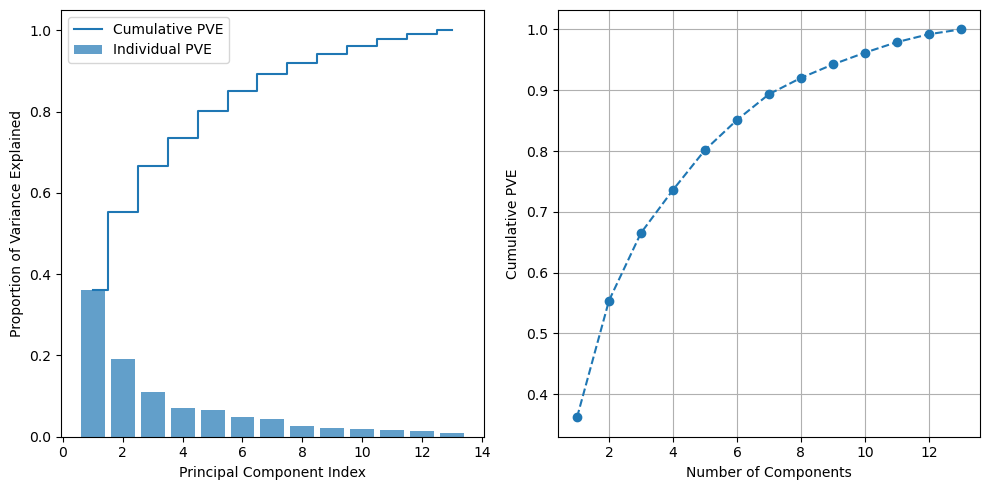

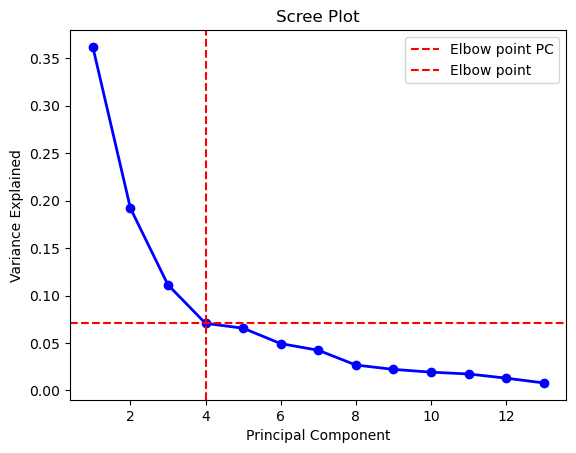

In [52]:
# Grade Cell: Question 5
#
# Task: Compute individual and cumulative variance explained
#
# Instructions:
# 1. Use q4_explained_variance_ratio to get individual PVE
# 2. Use np.cumsum() to compute cumulative PVE
# 3. Round values to 3 decimal places
# 4. Compute the sum of PC1 and PC2 variance

# your code here
# raise NotImplementedError

# ref
# https://numpy.org/doc/stable/reference/generated/numpy.around.html
# https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html#numpy-cumsum
# https://numpy.org/doc/stable/reference/generated/numpy.ndarray.tolist.html#numpy.ndarray.tolist

# Notes
# _npa means numpy array

# 1. Use q4_explained_variance_ratio to get individual PVE
# q5_pve: A list of individual Proportion of Variance Explained (PVE) for each component, rounded to 3 decimals
print('q4_explained_variance_ratio')
print(type(q4_explained_variance_ratio))
print(q4_explained_variance_ratio)
print('pve')
q5_pve_npa = np.round(q4_explained_variance_ratio,decimals=3)
print(f'q5_pve_npa: {q5_pve_npa}')
q5_pve = np.round(q4_explained_variance_ratio,decimals=3).tolist()
print(type(q5_pve))
print(q5_pve)

# 2. Use np.cumsum() to compute cumulative PVE
# q5_cumulative_pve: A list of cumulative PVE, rounded to 3 decimals
print('q5_cumulative_pve')
# q5_cumulative_pve_npa = np.cumsum(q5_pve_npa)
q5_cumulative_pve = np.round(np.cumsum(q5_pve), decimals=3).tolist()
print(type(q5_cumulative_pve))
print(q5_cumulative_pve)

# 4. Compute the sum of PC1 and PC2 variance
# q5_pc1_pc2_total: The total variance explained by PC1 and PC2 combined (float, rounded to 3 decimals)
# q5_pc1_pc2_total = q5_pve[0] + q5_pve[1]
q5_pc1_pc2_total = q5_cumulative_pve[1]
print(f'q5_pc1_pc2_total: \n{q5_pc1_pc2_total}')



# EXPLORE

# Note:
# - took the below code from Google AI mode (gemini) with prompt 
# "Proportion of Variance Explained (PVE) with PCA"
# to try understand it better and i realized it was simpler than others found in the 
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html docs.
# So I put it here for now.

pve = q4_explained_variance_ratio
cumulative_pve = np.cumsum(pve)

# 4. Plot Scree Plot and Cumulative PVE
plt.figure(figsize=(10, 5))

# Individual PVE (Scree Plot)
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pve) + 1), pve, alpha=0.7, align='center', label='Individual PVE')
plt.step(range(1, len(pve) + 1), cumulative_pve, where='mid', label='Cumulative PVE')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component Index')
plt.legend(loc='best')

# Cumulative PVE alone
plt.subplot(1, 2, 2)
plt.plot(range(1, len(pve) + 1), cumulative_pve, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative PVE')
plt.grid()

plt.tight_layout()
plt.show()

# spree plot
# this was an estimate as the elbow point was subjective
# later a threshold of 80% from cumulative was used to determine the correct number of PCs.

# code from https://www.statology.org/scree-plot-python/
# explaination https://sanchitamangale12.medium.com/scree-plot-733ed72c8608
PC_values = np.arange(q4_pca.n_components_) + 1
plt.plot(PC_values, q4_pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Elbow point PC')
plt.axhline(y=q4_pca.explained_variance_ratio_[3], color='red', linestyle='--', linewidth=1.5, label='Elbow point')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.show()

# EXPLORE END


# BEGIN HIDDEN TESTS
# PC1 + PC2 should explain ~55% of variance
assert 0.50 < q5_pc1_pc2_total < 0.65, (
    "PC1 + PC2 should explain approximately 55% of variance."
)
# END HIDDEN TESTS



In [12]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert isinstance(q5_pve, list), (
    "q5_pve must be a list of floats."
)
assert isinstance(q5_cumulative_pve, list), (
    "q5_cumulative_pve must be a list of floats."
)
assert len(q5_pve) == q4_n_components, (
    f"q5_pve should have {q4_n_components} entries."
)
assert len(q5_cumulative_pve) == q4_n_components, (
    f"q5_cumulative_pve should have {q4_n_components} entries."
)
# PVE values should be decreasing
assert all(q5_pve[i] >= q5_pve[i+1] for i in range(len(q5_pve)-1)), (
    "PVE values should be in decreasing order (PC1 explains most, then PC2, etc.)."
)
# Cumulative should be increasing
assert all(q5_cumulative_pve[i] <= q5_cumulative_pve[i+1] for i in range(len(q5_cumulative_pve)-1)), (
    "Cumulative PVE should be increasing."
)
# Last cumulative value should be ~1.0
assert abs(q5_cumulative_pve[-1] - 1.0) < 0.01, (
    "Final cumulative PVE should be ~1.0 (all variance explained)."
)
assert isinstance(q5_pc1_pc2_total, float), (
    "q5_pc1_pc2_total must be a float."
)
print(f"Individual PVE: {q5_pve}")
print(f"Cumulative PVE: {q5_cumulative_pve}")
print(f"PC1 + PC2 explain {q5_pc1_pc2_total*100:.1f}% of total variance")

Individual PVE: [0.386, 0.169, 0.114, 0.077, 0.066, 0.051, 0.046, 0.027, 0.021, 0.019, 0.015, 0.009]
Cumulative PVE: [0.386, 0.555, 0.669, 0.746, 0.812, 0.863, 0.909, 0.936, 0.957, 0.976, 0.991, 1.0]
PC1 + PC2 explain 55.5% of total variance


## 6. Choose Number of Components *(10 points)*

How many components should we keep? Common approaches include:
1. **Variance threshold**: Keep enough components to explain a target amount (e.g., 80%) of variance
2. **Scree plot elbow**: Look for where variance drops off sharply

Find the **minimum number of components** needed to explain at least **80%** of the variance.

Store the results as:
- **`q6_threshold`**: The variance threshold we're using (0.8)
- **`q6_n_components_80`**: The minimum number of components to explain ≥80% variance (integer)
- **`q6_actual_variance`**: The actual variance explained by those components (float, rounded to 3 decimals)

q5_cumulative_pve: 
[0.362, 0.554, 0.665, 0.736, 0.802, 0.851, 0.893, 0.92, 0.942, 0.961, 0.978, 0.991, 0.999]
indices_pre_80: 
[0, 1, 2, 3]
indices_post_80: 
[4, 5, 6, 7, 8, 9, 10, 11, 12]
first_index_80: 4
0.802
q6_n_components_80: 5 to keep!
variances_post_80: [0.802, 0.851, 0.893, 0.92, 0.942, 0.961, 0.978, 0.991, 0.999]
variances_upto_80: [0.362, 0.554, 0.665, 0.736, 0.802]
0.802


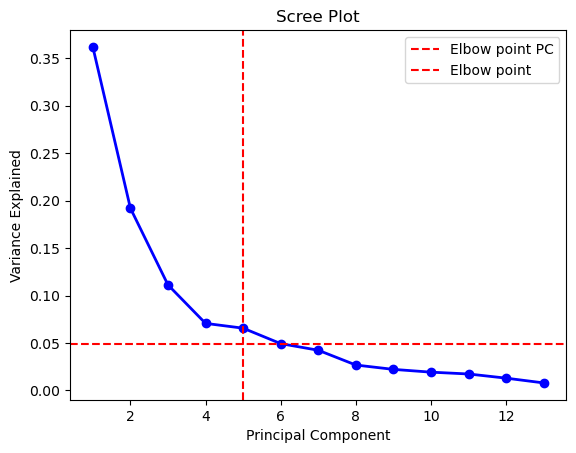

In [53]:
# Grade Cell: Question 6
#
# Task: Find minimum components to explain 80% of variance
#
# Instructions:
# 1. Use the cumulative variance from Q5
# 2. Find the first index where cumulative variance >= 0.8
# 3. Remember: the number of components is index + 1

# your code here
# raise NotImplementedError

# Refs
# https://www.geeksforgeeks.org/python/check-if-value-exists-in-python-list-of-objects/#:~:text=of%20all%20matches.-,Using%20next(),-The%20next()
# https://www.geeksforgeeks.org/python/python-next-method/
# https://cinnipatel.medium.com/principal-component-analysis-python-a6214346cae7

# 1. Use the cumulative variance from Q5
print(f'q5_cumulative_pve: \n{q5_cumulative_pve}')


# 2. Find the first index where cumulative variance >= 0.8
# q6_threshold: The variance threshold we're using (0.8)
q6_threshold = 0.8

# Find the first number divisible by 3
# some cons to using next() but it felt fine here for now. At higher dimensions this could be replaced with filter/loop
# first_match = next((n for n in q5_cumulative_pve if n >= 0.8), None)
# print(first_match)

# realized i needed the index so used numpy for potentially large dimensions
# indices = np.where(q5_cumulative_pve >= 0.8)
# first_match = next((n for  in enumerate(q5_cumulative_pve) if n >= 0.8), None)

# get low 

indices_pre_80 = [i for i, v in enumerate(q5_cumulative_pve) if v <= q6_threshold]
print(f'indices_pre_80: \n{indices_pre_80}')

# works but just have to select the first index. 
indices_post_80 = [i for i, v in enumerate(q5_cumulative_pve) if v >= q6_threshold]
print(f'indices_post_80: \n{indices_post_80}')
# first_match = indices[0]

# get first index to threshold

# liked the default of None if the PVE happens to be empty. Not required just wanted to try.
# the syntax is a little unusual here as next expects a generator with () not [] to work.
first_index_80 = next((i for i, v in enumerate(q5_cumulative_pve) if v >= q6_threshold), None)
print(f'first_index_80: {first_index_80}')

# 3. Remember: the number of components is index + 1
# q6_n_components_80: The minimum number of components to explain ≥80% variance (integer)

# this was confusing as I thought it was all PC after 80
# q6_n_components_80 = len(indices_post_80)
print(q5_cumulative_pve[first_index_80])
q6_n_components_80 = first_index_80+1
print(f'q6_n_components_80: {q6_n_components_80} to keep!')

# q6_actual_variance: The actual variance explained by those components (float, rounded to 3 decimals)

# wrong as its all up to index not after
variances_post_80 = q5_cumulative_pve[4:]
print(f'variances_post_80: {variances_post_80}')

# selection matches all up but excluding the index e.g [start:stop:step]
variances_upto_80 = q5_cumulative_pve[:q6_n_components_80]
print(f'variances_upto_80: {variances_upto_80}')

# confused by "actual variance explained" to mean mean or sum...its just the final cumulative value, so last
# q6_actual_variance = np.mean(variances_upto_80)
q6_actual_variance = variances_upto_80[-1]
print(q6_actual_variance)



# spree plot
# this is accurate per the threshold to get the elbow point was subjective
# later a threshold of 80% from cumulative was used to determine the correct number of PCs.

# code from https://www.statology.org/scree-plot-python/
# explaination https://sanchitamangale12.medium.com/scree-plot-733ed72c8608
# PC_values = np.arange(q4_pca.n_components_) + 1
plt.plot(PC_values, q4_pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.axvline(x=q6_n_components_80, color='red', linestyle='--', linewidth=1.5, label='Elbow point PC')
plt.axhline(y=q4_pca.explained_variance_ratio_[q6_n_components_80], color='red', linestyle='--', linewidth=1.5, label='Elbow point')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.show()


# BEGIN HIDDEN TESTS
# For wine data, 5 components explain ~80% of variance
assert q6_n_components_80 == 5, (
    "5 components are needed to explain ≥80% of variance in the wine data."
)
assert 0.80 <= q6_actual_variance <= 0.85, (
    "Actual variance should be between 80% and 85%."
)
# END HIDDEN TESTS


In [14]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert q6_threshold == 0.8, (
    "q6_threshold should be 0.8 (80% variance threshold)."
)
assert isinstance(q6_n_components_80, int), (
    "q6_n_components_80 must be an integer."
)
assert 1 <= q6_n_components_80 <= q4_n_components, (
    f"Number of components should be between 1 and {q4_n_components}."
)
assert isinstance(q6_actual_variance, float), (
    "q6_actual_variance must be a float."
)
assert q6_actual_variance >= q6_threshold, (
    f"Actual variance ({q6_actual_variance}) should be >= threshold ({q6_threshold}). "
    "Did you find the right number of components?"
)
# Check that one fewer component doesn't meet threshold
if q6_n_components_80 > 1:
    prev_variance = sum(q5_pve[:q6_n_components_80-1])
    assert prev_variance < q6_threshold, (
        "You might have selected more components than necessary. "
        "Find the MINIMUM number needed to reach 80%."
    )
print(f"Threshold: {q6_threshold*100:.0f}%")
print(f"Components needed: {q6_n_components_80}")
print(f"Actual variance explained: {q6_actual_variance*100:.1f}%")

Threshold: 80%
Components needed: 5
Actual variance explained: 81.2%


## 7. Examine Loadings *(10 points)*

**Loadings** tell us how each original feature contributes to each principal component.
By examining loadings, we can interpret what each PC represents.

For PC1 and PC2:
- Find the features with the **largest absolute loadings**
- These are the features that drive each component

Store the results as:
- **`q7_loadings`**: A numpy array of shape (n_components, n_features) containing all loadings
- **`q7_pc1_top_feature`**: The name of the feature with the largest absolute loading on PC1
- **`q7_pc2_top_feature`**: The name of the feature with the largest absolute loading on PC2
- **`q7_pc1_top_loading`**: The loading value of the top feature on PC1 (rounded to 3 decimals)

In [54]:
# Grade Cell: Question 7
#
# Task: Examine and interpret PCA loadings
#
# Instructions:
# 1. Access the loadings from pca.components_
# 2. For PC1 (index 0), find the feature with largest |loading|
# 3. For PC2 (index 1), find the feature with largest |loading|
# 4. Use q1_columns to get feature names

# your code here
# raise NotImplementedError

# Refs
# https://www.jcchouinard.com/pca-loadings/#:~:text=Python%20Example%20of%20PCA%20Loadings,loadings_df
# https://cinnipatel.medium.com/principal-component-analysis-python-a6214346cae7
# https://rhydhamgupta.medium.com/pca-eigenvalue-eigenvector-principal-component-explained-in-python-2afb44c4990d
# https://www.kdnuggets.com/2023/05/principal-component-analysis-pca-scikitlearn.html
# https://insidelearningmachines.com/biplot/#:~:text=)%5D)-,dfLoadings,-%3D%20pd

# Notes:
# - its kind of a mess as I experimented a lot here. 

# 3. Access the loadings (eigenvectors)
# pca.components_ returns a matrix with shape (n_components, n_features)
# After reading various sources, including the reading, seems like loadings can be 
# either pca.components_ which are the vectors or eigenvectors of the PCs, or
# via a formal operations where "eigenvectors by the square root of their corresponding eigenvalues" (from AI gemini).
# Seems like pca.components_ works but its not accurate but not sure how exactly. 
# per instructions using pca.components_ for now...

print(q4_pca.explained_variance_.shape)

# 1. Access the loadings from pca.components_
# q7_loadings: A numpy array of shape (n_components, n_features) containing all loadings
q7_loadings = q4_pca.components_

loadings_mx_pc2 = q7_loadings[:2]
loadings_mx_pc2_transpose = q7_loadings[:2].T

print(loadings_mx_pc2.shape)
print(loadings_mx_pc2)
print(loadings_mx_pc2_transpose.shape)
print(loadings_mx_pc2_transpose)

feature_names = q1_columns

# DF mapping loadings matrix to columns and features
# mostly experimenting with some help from ai and refs.
# the transpose worked bacause the per refs the visual it PCs are columns.
loadings_df = pd.DataFrame(
    loadings_mx_pc2_transpose, 
    columns=['PC1', 'PC2'], 
    index=feature_names
)

print(loadings_df)

# formal loadings calc where eigenvectors * sqrt(eigenvalues)
loadings = q4_pca.components_.T * np.sqrt(q4_pca.explained_variance_)
print(f'loadings 2 PCs: {loadings[:2]}')

loadings_df_calc = pd.DataFrame(
    loadings[:2].T, 
    columns=['PC1', 'PC2'], 
    index=feature_names
)

print(loadings_df_calc)
print('seems like loadings matrix with just components_ vs the formal calc differ.')


# q7_pc1_top_feature: The name of the feature with the largest absolute loading on PC1
pc1_value_abs_max = np.max(np.abs(loadings_df['PC1']))
print(f'pc1_value_abs_max: {pc1_value_abs_max}')

print(f'ddd \n{np.abs(loadings_df.values).argmax()}')

print('abs and idxmax chain:')
print(loadings_df.abs().idxmax(axis=1))
print(loadings_df.abs().idxmax())

# Find index of max absolute value
idx = loadings_df['PC1'].abs().idxmax()

# Access the original row using .loc
original_row = loadings_df.loc[idx]
print(f'original_row: \n{original_row}')

print(f'max value: \n{loadings_df.abs().max()}')
print(f'max label value: \n{loadings_df.abs().idxmax()}')

abs_max_loadings = pd.DataFrame({
    'abs_max_value': loadings_df.abs().max(),
    'feature': loadings_df.abs().idxmax()
})
print(f'summary: \n{abs_max_loadings}')

print(f'label for PC1: {abs_max_loadings.loc["PC1", "feature"]}')
q7_pc1_top_feature = abs_max_loadings.loc["PC1", "feature"]

# q7_pc2_top_feature: The name of the feature with the largest absolute loading on PC2
q7_pc2_top_feature = abs_max_loadings.loc["PC2", "feature"]

# q7_pc1_top_loading: The loading value of the top feature on PC1 (rounded to 3 decimals)
print(f'top feature value', abs_max_loadings.max())
# q7_pc1_top_loading = np.round(abs_max_loadings.max(), decimals=3)
# q7_pc1_top_loading = abs_max_loadings.max()
q7_pc1_top_loading = round(abs_max_loadings['abs_max_value'].max(), 3)
print(f'type q7_pc1_top_loading: {type(q7_pc1_top_loading)} : {q7_pc1_top_loading}')


# BEGIN HIDDEN TESTS
# For wine data, flavanoids typically has high loading on PC1
assert q7_pc1_top_feature in ["flavanoids", "total_phenols", "od280/od315_of_diluted_wines"], (
    "PC1 should be driven by phenolic compounds like flavanoids or total_phenols."
)
assert abs(q7_pc1_top_loading) > 0.3, (
    "Top loading on PC1 should have magnitude > 0.3."
)
# END HIDDEN TESTS


(13,)
(2, 13)
[[-0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085  0.4229343
  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741  0.28675223
   0.1443294 ]
 [-0.22493093 -0.31606881  0.0105905  -0.299634   -0.06503951  0.00335981
  -0.02877949 -0.03930172 -0.52999567  0.27923515  0.16449619 -0.36490283
  -0.48365155]]
(13, 2)
[[-0.24518758 -0.22493093]
 [-0.00205106 -0.31606881]
 [-0.23932041  0.0105905 ]
 [ 0.14199204 -0.299634  ]
 [ 0.39466085 -0.06503951]
 [ 0.4229343   0.00335981]
 [-0.2985331  -0.02877949]
 [ 0.31342949 -0.03930172]
 [-0.0886167  -0.52999567]
 [ 0.29671456  0.27923515]
 [ 0.37616741  0.16449619]
 [ 0.28675223 -0.36490283]
 [ 0.1443294  -0.48365155]]
                                   PC1       PC2
malic_acid                   -0.245188 -0.224931
ash                          -0.002051 -0.316069
alcalinity_of_ash            -0.239320  0.010591
magnesium                     0.141992 -0.299634
total_phenols                 0.394661 -0.065040
flavan

In [16]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(q7_loadings, np.ndarray), (
    "q7_loadings must be a numpy array."
)
assert q7_loadings.shape == (q4_n_components, q1_n_features), (
    f"Loadings shape should be ({q4_n_components}, {q1_n_features})."
)
# Loadings should be unit vectors (rows have norm 1)
for i in range(min(3, q4_n_components)):
    row_norm = np.linalg.norm(q7_loadings[i, :])
    assert np.isclose(row_norm, 1.0, atol=0.01), (
        f"Row {i} of loadings should have norm 1.0 (unit vector), got {row_norm:.3f}."
    )
assert isinstance(q7_pc1_top_feature, str), (
    "q7_pc1_top_feature must be a string (feature name)."
)
assert q7_pc1_top_feature in q1_columns, (
    "q7_pc1_top_feature must be one of the original feature names."
)
assert isinstance(q7_pc2_top_feature, str), (
    "q7_pc2_top_feature must be a string (feature name)."
)
assert q7_pc2_top_feature in q1_columns, (
    "q7_pc2_top_feature must be one of the original feature names."
)
assert isinstance(q7_pc1_top_loading, float), (
    "q7_pc1_top_loading must be a float."
)
assert -1 <= q7_pc1_top_loading <= 1, (
    "Loadings should be between -1 and 1."
)
print(f"Loadings shape: {q7_loadings.shape}")
print(f"PC1 top feature: {q7_pc1_top_feature} (loading: {q7_pc1_top_loading})")
print(f"PC2 top feature: {q7_pc2_top_feature}")

Loadings shape: (12, 12)
PC1 top feature: flavanoids (loading: 0.536)
PC2 top feature: color_intensity


## 8. Transform Data to PC Space *(10 points)*

Now let's transform the standardized data to principal component space. This gives us
the **scores** - the coordinates of each observation in the new PC coordinate system.

Transform the data and store in a DataFrame for easier analysis.

Store the results as:
- **`q8_scores`**: A numpy array of shape (n_samples, n_components) with the transformed data
- **`q8_scores_df`**: A pandas DataFrame with the scores, with columns named "PC1", "PC2", etc.
- **`q8_pc1_range`**: A tuple (min, max) of PC1 scores (values rounded to 2 decimals)

In [55]:
# Grade Cell: Question 8
#
# Task: Transform data to principal component space
#
# Instructions:
# 1. Use pca.transform() on the standardized data
# 2. Create a DataFrame with column names "PC1", "PC2", etc.
# 3. Find the range (min, max) of PC1 scores

# your code here
# raise NotImplementedError

# refs
# https://insidelearningmachines.com/biplot/#:~:text=perform%20PCA%2C%20and-,store%20the%20scores,-and%20loadings%20in
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.transform

# 1. Use pca.transform() on the standardized data
# q8_scores: A numpy array of shape (n_samples, n_components) with the transformed data
q8_scores = q4_pca.fit_transform(df)
print(f'q8_scores shape: {q8_scores.shape}')
print(f'q8_scores 2 rows: \n{q8_scores[:2]}')


# 2. Create a DataFrame with column names "PC1", "PC2", etc.
# q8_scores_df: A pandas DataFrame with the scores, with columns named "PC1", "PC2", etc.
display(f'df.head: \n{df.head()}')
print(f'column names: \n{df.columns}')
print(f'column names list: \n{q1_columns}')
print(f'PCs: \n{len(q4_explained_variance_ratio)}')
print(f'transpose scores to (n_components, n_samples): {q8_scores.T.shape}')

# used the variance ratio as its just PCs making it easier that using a 2D array
pc_names_list = [f"PC{v}" for v in range(1, len(q4_explained_variance_ratio)+1)]
print(f'column names list: \n{pc_names_list}')

# create dataframe to interpret better
q8_scores_df   = pd.DataFrame(q8_scores, columns=pc_names_list)
print(f'q8_scores_df shape: {q8_scores_df.shape}')
display(q8_scores_df[:2])
print(q8_scores_df.PC1)
# display(q8_scores_df[[0,1,18]])
# display(q8_scores_df[np.r_[:2, 18], :])

# 3. Find the range (min, max) of PC1 scores
# q8_pc1_range: A tuple (min, max) of PC1 scores (values rounded to 2 decimals)
print(f'max for PC1: {q8_scores_df["PC1"].max()}')
print(f'max sample index for PC1: {q8_scores_df["PC1"].idxmax()}')
print(f'min for PC1: {q8_scores_df["PC1"].min()}')
q8_pc1_range = (q8_scores_df["PC1"].min(), q8_scores_df["PC1"].max())
print(f'q8_pc1_range: {q8_pc1_range}')

q8_pc2_range = (q8_scores_df["PC2"].min(), q8_scores_df["PC2"].max())
print(f'q8_pc2_range: {q8_pc2_range}')


# BEGIN HIDDEN TESTS
# PC scores should be centered (mean ~0)
assert abs(q8_scores[:, 0].mean()) < 0.01, "PC1 scores should be centered (mean ~0)."
assert abs(q8_scores[:, 1].mean()) < 0.01, "PC2 scores should be centered (mean ~0)."
# END HIDDEN TESTS


q8_scores shape: (178, 13)
q8_scores 2 rows: 
[[ 3.18562979e+02  2.14921307e+01  3.13073470e+00 -2.50113758e-01
   6.77078222e-01  5.68081040e-01 -6.19641832e-01 -1.99555377e-01
   7.01280283e-01 -9.50075663e-02  8.87340044e-02 -3.85475626e-02
   8.02644337e-02]
 [ 3.03097420e+02 -5.36471768e+00  6.82283550e+00 -8.64034749e-01
  -4.86095978e-01  1.43398712e-02  1.08865121e-01  6.04714449e-01
   2.86716849e-01 -4.57819758e-02  3.97781862e-02 -5.71915771e-02
   1.35927465e-02]]


'df.head: \n         malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \\\nalcohol                                                                  \n14.23          1.71  2.43               15.6      127.0           2.80   \n13.20          1.78  2.14               11.2      100.0           2.65   \n13.16          2.36  2.67               18.6      101.0           2.80   \n14.37          1.95  2.50               16.8      113.0           3.85   \n13.24          2.59  2.87               21.0      118.0           2.80   \n\n         flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  \\\nalcohol                                                                       \n14.23          3.06                  0.28             2.29             5.64   \n13.20          2.76                  0.26             1.28             4.38   \n13.16          3.24                  0.30             2.81             5.68   \n14.37          3.49                  0.24             2.18 

column names: 
Index(['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols',
       'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins',
       'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline',
       'alcohol'],
      dtype='object')
column names list: 
['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'alcohol']
PCs: 
13
transpose scores to (n_components, n_samples): (13, 178)
column names list: 
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13']
q8_scores_df shape: (178, 13)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,318.562979,21.492131,3.130735,-0.250114,0.677078,0.568081,-0.619642,-0.199555,0.701280,-0.095008,0.088734,-0.038548,0.080264
1,303.097420,-5.364718,6.822835,-0.864035,-0.486096,0.014340,0.108865,0.604714,0.286717,-0.045782,0.039778,-0.057192,0.013593


0      318.562979
1      303.097420
2      438.061133
3      733.240139
4      -11.571428
          ...    
173     -6.980211
174      3.131605
175     88.458074
176     93.456242
177   -186.943190
Name: PC1, Length: 178, dtype: float64
max for PC1: 933.1183874996057
max sample index for PC1: 18
min for PC1: -469.05935030926645
q8_pc1_range: (-469.05935030926645, 933.1183874996057)
q8_pc2_range: (-27.504038698491364, 58.793762379561834)


In [18]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 8
assert isinstance(q8_scores, np.ndarray), (
    "q8_scores must be a numpy array."
)
assert q8_scores.shape == (q1_shape[0], q4_n_components), (
    f"Scores shape should be ({q1_shape[0]}, {q4_n_components})."
)
assert isinstance(q8_scores_df, pd.DataFrame), (
    "q8_scores_df must be a pandas DataFrame."
)
assert q8_scores_df.shape == q8_scores.shape, (
    "DataFrame should have same shape as scores array."
)
assert "PC1" in q8_scores_df.columns, (
    "DataFrame columns should be named 'PC1', 'PC2', etc."
)
assert "PC2" in q8_scores_df.columns, (
    "DataFrame columns should be named 'PC1', 'PC2', etc."
)
assert isinstance(q8_pc1_range, tuple), (
    "q8_pc1_range must be a tuple (min, max)."
)
assert len(q8_pc1_range) == 2, (
    "q8_pc1_range should have exactly 2 elements (min, max)."
)
assert q8_pc1_range[0] < q8_pc1_range[1], (
    "First element should be min, second should be max."
)
print(f"Scores shape: {q8_scores.shape}")
print(f"DataFrame columns: {list(q8_scores_df.columns[:5])}...")
print(f"PC1 range: {q8_pc1_range}")

Scores shape: (178, 12)
DataFrame columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']...
PC1 range: (-469.0583356768349, 933.1176985257948)


## 9. Visualize PCA Results *(10 points)*

One of PCA's most powerful uses is **visualization**. By plotting PC1 vs PC2, we can
see structure in high-dimensional data that would otherwise be invisible.

Create a function to plot PC1 vs PC2 scores, and identify observations that are
outliers (far from the center in PC space).

Store the results as:
- **`q9_plot_created`**: Set to True after creating the scatter plot
- **`q9_pc1_pc2_corr`**: The correlation between PC1 and PC2 scores (should be ~0 since PCs are orthogonal)
- **`q9_furthest_from_origin`**: Index of the sample furthest from origin in PC1-PC2 space

q8_scores_df: (samples, components)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,318.562979,21.492131,3.130735,-0.250114,0.677078,0.568081,-0.619642,-0.199555,0.701280,-0.095008,0.088734,-0.038548,0.080264
1,303.097420,-5.364718,6.822835,-0.864035,-0.486096,0.014340,0.108865,0.604714,0.286717,-0.045782,0.039778,-0.057192,0.013593
2,438.061133,-6.537309,-1.113223,0.912411,0.380651,0.672404,0.785819,-0.500886,0.024547,-0.208960,0.237770,-0.048798,-0.035408
3,733.240139,0.192729,-0.917257,-0.541251,0.858662,0.599122,0.018770,0.190428,0.054277,0.531684,-0.096044,-0.166353,0.016344
4,-11.571428,18.489995,-0.554422,1.360896,0.276442,0.768884,-0.309976,0.119091,-0.195843,0.061771,0.316466,-0.007118,0.015278
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,-6.980211,-4.541137,-2.474707,-3.155920,-2.348927,1.439001,-0.026425,0.043705,0.040167,0.087377,0.016509,0.098355,0.027251
174,3.131605,2.335191,-4.309931,-1.562181,-1.168003,0.128679,0.003859,-0.303185,-0.159759,0.159510,-0.048916,0.012626,-0.042645
175,88.458074,18.776285,-2.237577,-4.820708,-1.057336,0.215000,0.648489,0.068966,0.273675,-0.045336,-0.223049,0.096049,0.036175
176,93.456242,18.670819,-1.788392,-3.709352,-0.276956,-1.009229,0.414948,-0.145647,0.254468,0.059211,-0.030408,-0.052089,0.132759


loadings_df


,PC1,PC2
malic_acid,-0.245188,-0.224931
ash,-0.002051,-0.316069
alcalinity_of_ash,-0.239320,0.010591
magnesium,0.141992,-0.299634
total_phenols,0.394661,-0.065040
flavanoids,0.422934,0.003360
nonflavanoid_phenols,-0.298533,-0.028779
proanthocyanins,0.313429,-0.039302
color_intensity,-0.088617,-0.529996
hue,0.296715,0.279235


loadings_df.T


,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,alcohol
PC1,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752,0.144329
PC2,-0.224931,-0.316069,0.010591,-0.299634,-0.065040,0.003360,-0.028779,-0.039302,-0.529996,0.279235,0.164496,-0.364903,-0.483652


loadings_df_all_pcs: similar to loadings_df.T but with all PCs


,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,alcohol
PC1,-0.245188,-0.002051,-0.239320,0.141992,0.394661,0.422934,-0.298533,0.313429,-0.088617,0.296715,0.376167,0.286752,0.144329
PC2,-0.224931,-0.316069,0.010591,-0.299634,-0.065040,0.003360,-0.028779,-0.039302,-0.529996,0.279235,0.164496,-0.364903,-0.483652
PC3,0.089013,0.626224,0.612080,0.130757,0.146179,0.150682,0.170368,0.149454,-0.137306,0.085222,0.166005,-0.126746,-0.207383
PC4,0.536890,-0.214176,0.060859,-0.351797,0.198068,0.152295,-0.203301,0.399057,0.065926,-0.427771,0.184121,-0.232071,-0.017856
PC5,0.035214,-0.143025,0.066103,0.727049,-0.149318,-0.109026,-0.500703,0.136860,-0.076437,-0.173615,-0.101161,-0.157869,-0.265664
PC6,-0.536814,-0.154475,0.100825,-0.038144,0.084122,0.018920,0.258594,0.533795,0.418644,-0.105983,-0.265851,-0.119726,-0.213539
PC7,0.420524,-0.149171,-0.286969,0.322883,-0.027925,-0.060685,0.595447,0.372139,-0.227712,0.232076,-0.044764,0.076805,-0.056396
PC8,-0.065827,0.170260,-0.427970,0.156361,0.405934,0.187245,0.233285,-0.368227,0.033797,-0.436624,0.078108,-0.120023,-0.396139
PC9,-0.075283,-0.307694,0.200449,0.271403,0.286035,0.049578,0.195501,-0.209145,0.056218,0.085828,0.137227,-0.575786,0.508619
PC10,-0.309080,-0.027125,0.052799,0.067870,-0.320131,-0.163151,0.215535,0.134184,-0.290775,-0.522399,0.523706,0.162116,0.211605


Index(['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols',
       'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins',
       'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline',
       'alcohol'],
      dtype='object')
BIPLOT OF PC1(PC2)


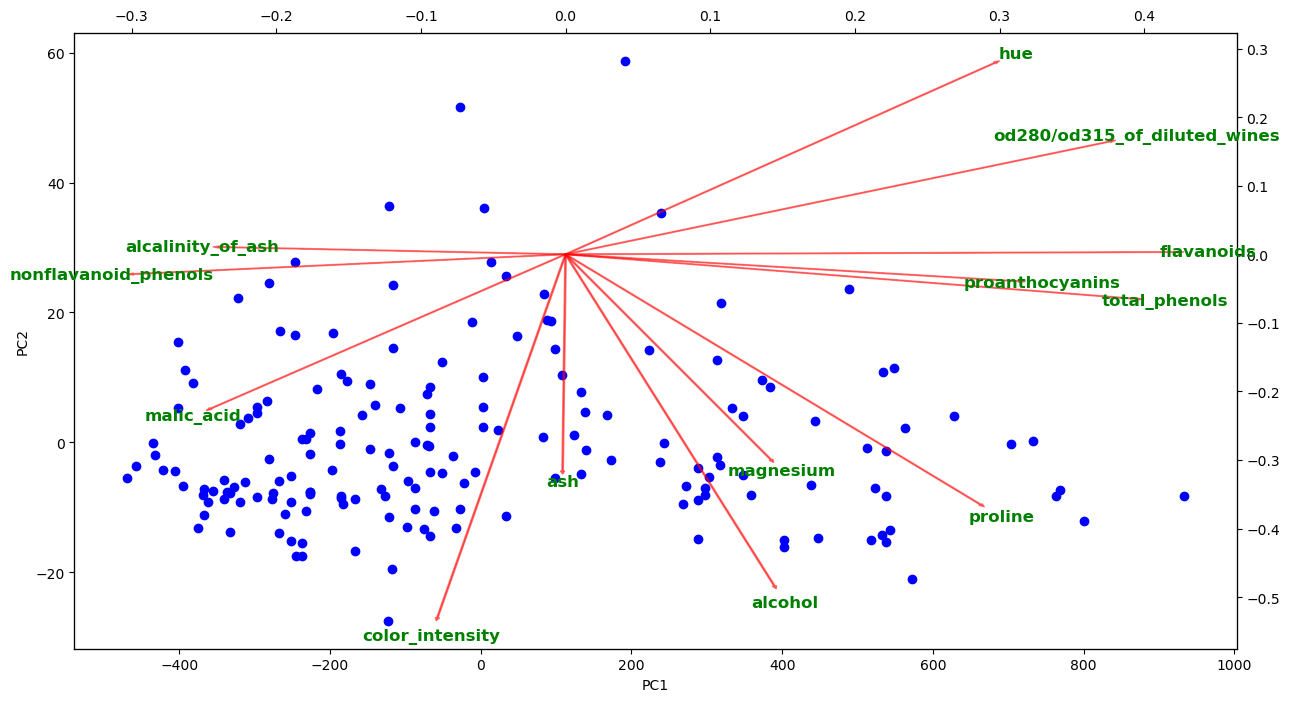

correlation_matrix: 
[[ 1.00000000e+00  4.79753941e-17  1.11928171e-16  8.11727515e-17
  -1.10144185e-16 -1.88763146e-16 -1.40613403e-17 -8.59903088e-17
   4.87271056e-17  2.66549425e-17 -1.73582508e-16  7.02409730e-18
  -3.89850423e-17]
 [ 4.79753941e-17  1.00000000e+00  5.24531934e-16  8.06249779e-17
  -1.87123964e-16  2.84670599e-16  6.02014725e-17  1.91995003e-17
   3.87945205e-17  8.98795934e-17 -2.68022817e-16 -1.05266783e-17
  -1.33044947e-17]
 [ 1.11928171e-16  5.24531934e-16  1.00000000e+00 -2.48684259e-16
   1.19228127e-16 -1.14193355e-16 -4.58335682e-17  1.65742790e-17
  -1.15254960e-16 -4.11737724e-17  1.96961261e-16 -7.03246717e-18
  -1.45173679e-17]
 [ 8.11727515e-17  8.06249779e-17 -2.48684259e-16  1.00000000e+00
  -7.06308427e-17  3.47376585e-16 -5.82913411e-17 -8.96624629e-17
   1.38363906e-17  2.22281750e-16 -3.76576838e-17  2.32091910e-17
   3.87375252e-17]
 [-1.10144185e-16 -1.87123964e-16  1.19228127e-16 -7.06308427e-17
   1.00000000e+00 -1.53154556e-16  7.67718199

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
PC1,1.000000e+00,4.797539e-17,1.119282e-16,8.117275e-17,-1.101442e-16,-1.887631e-16,-1.406134e-17,-8.599031e-17,4.872711e-17,2.665494e-17,-1.735825e-16,7.024097e-18,-3.898504e-17
PC2,4.797539e-17,1.000000e+00,5.245319e-16,8.062498e-17,-1.871240e-16,2.846706e-16,6.020147e-17,1.919950e-17,3.879452e-17,8.987959e-17,-2.680228e-16,-1.052668e-17,-1.330449e-17
PC3,1.119282e-16,5.245319e-16,1.000000e+00,-2.486843e-16,1.192281e-16,-1.141934e-16,-4.583357e-17,1.657428e-17,-1.152550e-16,-4.117377e-17,1.969613e-16,-7.032467e-18,-1.451737e-17
PC4,8.117275e-17,8.062498e-17,-2.486843e-16,1.000000e+00,-7.063084e-17,3.473766e-16,-5.829134e-17,-8.966246e-17,1.383639e-17,2.222817e-16,-3.765768e-17,2.320919e-17,3.873753e-17
PC5,-1.101442e-16,-1.871240e-16,1.192281e-16,-7.063084e-17,1.000000e+00,-1.531546e-16,7.677182e-17,1.675288e-17,5.408064e-17,1.690483e-17,7.005586e-17,-2.728536e-17,-5.559112e-17
PC6,-1.887631e-16,2.846706e-16,-1.141934e-16,3.473766e-16,-1.531546e-16,1.000000e+00,-3.156125e-16,-1.220927e-16,2.451360e-17,4.597561e-17,4.233978e-17,-3.769258e-17,-7.119975e-18
PC7,-1.406134e-17,6.020147e-17,-4.583357e-17,-5.829134e-17,7.677182e-17,-3.156125e-16,1.000000e+00,-8.143196e-18,5.675170e-17,3.547954e-17,-3.063165e-17,7.362772e-17,3.594540e-17
PC8,-8.599031e-17,1.919950e-17,1.657428e-17,-8.966246e-17,1.675288e-17,-1.220927e-16,-8.143196e-18,1.000000e+00,-1.853809e-16,-1.926564e-16,-1.164324e-16,2.110075e-16,-5.470095e-17
PC9,4.872711e-17,3.879452e-17,-1.152550e-16,1.383639e-17,5.408064e-17,2.451360e-17,5.675170e-17,-1.853809e-16,1.000000e+00,2.938477e-16,-1.884603e-16,-9.679324e-18,8.144195e-17
PC10,2.665494e-17,8.987959e-17,-4.117377e-17,2.222817e-16,1.690483e-17,4.597561e-17,3.547954e-17,-1.926564e-16,2.938477e-16,1.000000e+00,-3.791387e-16,2.985277e-16,-1.719941e-16


corr PC1 & PC2: 4.7975394104719937e-17
corr PC1 & PC2 method 2: 4.7975394104719937e-17
corr PC1 & PC2 method 3: 4.7975394104719937e-17
corr PC1 & PC2 method df: 4.7975394104719937e-17
pc_squared: 
0      101482.371773
1       91868.045804
2      191897.556173
3      537641.101955
4         133.897957
           ...      
173        48.723345
174         9.806948
175      7824.830800
176      8734.069141
177     34947.756389
Name: PC1, Length: 178, dtype: float64
sum_pcs_squared: 
0      101944.283456
1       91896.826000
2      191940.292588
3      537641.139100
4         475.777858
           ...      
173        69.345266
174        15.260063
175      8177.379662
176      9082.668628
177     34947.801900
Length: 178, dtype: float64
sqrt_vector: 
0      17.848333
1      17.409693
2      20.929910
3      27.078407
4            NaN
         ...    
173          NaN
174     1.769634
175     9.405215
176     9.667277
177          NaN
Name: PC1, Length: 178, dtype: float64
sample_distances

,Eucleadian Distance
0,319.287149
1,303.144893
2,438.109909
3,733.240165
4,21.812333
...,...
173,8.327381
174,3.906413
175,90.428865
176,95.303036


max sample_distances: 
933.1557867793911 
 max index sample_distances: 
18


In [56]:
# Grade Cell: Question 9
#
# Task: Visualize PCA results and identify outliers
#
# Instructions:
# 1. Create a scatter plot of PC1 vs PC2
# 2. Calculate correlation between PC1 and PC2 scores
# 3. Find the sample furthest from origin (largest sqrt(PC1^2 + PC2^2))

# your code here
# raise NotImplementedError

# ref
# https://insidelearningmachines.com/biplot/#:~:text=no%20out%2Dof%2Dthe%2Dbox%20biplot
# https://nirpyresearch.com/pca-correlation-circle/#:~:text=First%2C%20we%20calculate%20the%20correlation,+%20corr2**2))
# https://realpython.com/numpy-scipy-pandas-correlation-python/#linear-correlation:~:text=recall%20that%20np.corrcoef()%20can%20take%20two%20NumPy%20arrays%20as%20arguments.

# From ref
# pca        = PCA()
# scores     = pca.fit_transform(X)
# dfScores   = pd.DataFrame(scores,columns=['PC'+str(i) for i in range(1,dfX.shape[1]+1)])
# dfLoadings = pd.DataFrame(pca.components_,columns=dfX.columns,index=dfScores.columns)

# Notes
# scores vs loadings
# scores refer to samples/observations on PCs, where high is outlier
# loadings refer to columns/features/dimensions on PCs, where high is closer to 1 or -1 means heavy importance


# import mpl_axes_aligner

print('q8_scores_df: (samples, components)')
display(q8_scores_df)

# from ref
# dfLoadings = pd.DataFrame(q7_loadings[:2].T,columns=['PC1', 'PC2'],index=feature_names)
loadings_df_all_pcs = pd.DataFrame(q7_loadings,columns=df.columns,index=q8_scores_df.columns)
# print(f'dfLoadings: \n{dfLoadings}')

print('loadings_df')
display(loadings_df)

print('loadings_df.T')
display(loadings_df.T)

print('loadings_df_all_pcs: similar to loadings_df.T but with all PCs')
display(loadings_df_all_pcs)
# print(f'dfLoadings.columns: \n{dfLoadings.columns}')
# print(f'dfLoadings.columns.values: \n{dfLoadings.columns.values}')
# print(f'dfLoadings.loc: \n{dfLoadings.loc["PC1","PC1"]}')

print(df.columns)

#     for col in dfLoadings.columns.values:
#         #where do our loading vectors end?
#         tipx = dfLoadings.loc['PC1',col]
#         tipy = dfLoadings.loc['PC2',col]


# biplot
# mostly copied from ref 
# print(q8_scores_df.PC1.values)

#function to produce biplot
def biplot(dfScores: pd.DataFrame, dfLoadings: pd.DataFrame) -> None:
    
    #create figure and axis objects
    fig,ax = plt.subplots(figsize=(15,8))
    
    #make a scores plot
    ax.scatter(dfScores.PC1.values,dfScores.PC2.values, color='b')
    #set x-axis label
    ax.set_xlabel("PC1",fontsize=10)
    #set y-axis label
    ax.set_ylabel("PC2",fontsize=10)
    
#     create a second set of axes
    ax2 = ax.twinx().twiny()
    
    #setup font dictionary
    font = {'color':  'g',
            'weight': 'bold',
            'size': 12,
            }
    
    #make a loadings plot
    for col in dfLoadings.columns.values:
        #where do our loading vectors end?
        tipx = dfLoadings.loc['PC1',col]
        tipy = dfLoadings.loc['PC2',col]
        #draw the vector, and write label text for col
        ax2.arrow(0, 0, tipx, tipy, color = 'r', alpha = 0.5)
        ax2.text(tipx*1.05, tipy*1.05, col, fontdict = font, ha = 'center', va = 'center')
    
    #align x = 0 of ax and ax2 with the center of figure
#     mpl_axes_aligner.align.xaxes(ax, 0, ax2, 0, 0.5)
#     #align y = 0 of ax and ax2 with the center of figure
#     mpl_axes_aligner.align.yaxes(ax, 0, ax2, 0, 0.5)
    
    #show plot
    plt.show()

# 1. Create a scatter plot of PC1 vs PC2
# q9_plot_created: Set to True after creating the scatter plot
print('BIPLOT OF PC1(PC2)')
biplot(q8_scores_df, loadings_df_all_pcs)
q9_plot_created = True

# 2. Calculate correlation between PC1 and PC2 scores
# q9_pc1_pc2_corr: The correlation between PC1 and PC2 scores (should be ~0 since PCs are orthogonal)

# Calculate correlation between PC1 (col 0) and PC2 (col 1)
# correlation_matrix = np.corrcoef(q8_scores[:, 0], q8_scores[:, 1])
# rowvar defaults to True using rows/samples. So needed to disable for it to use columns/PCs
correlation_matrix = np.corrcoef(q8_scores_df, rowvar=False)
# taken form AI (gemini) which shows using 2 vectors over 2D arrays but both work
correlation_matrix_2 = np.corrcoef(q8_scores_df['PC1'], q8_scores_df['PC2'])
# alt is to transpose
correlation_matrix_3 = np.corrcoef(q8_scores_df.T)

print(f'correlation_matrix: \n{correlation_matrix} | shape {correlation_matrix.shape}')
print(f'correlation_matrix_2: \n{correlation_matrix_2} | shape {correlation_matrix_2.shape}')
print(f'correlation_matrix_3: \n{correlation_matrix_3} | shape {correlation_matrix_3.shape}')

print('correlation_matrix & correlation_matrix_2 & 3 are the same but ran slightly different.')

correlation_matrix_df = pd.DataFrame(correlation_matrix, index=pc_names_list, columns=pc_names_list)
print('correlation_matrix_df')
display(correlation_matrix_df)

print(f'corr PC1 & PC2: {correlation_matrix[0, 1]}')
print(f'corr PC1 & PC2 method 2: {correlation_matrix_2[0, 1]}')
print(f'corr PC1 & PC2 method 3: {correlation_matrix_3[0, 1]}')
print(f'corr PC1 & PC2 method df: {correlation_matrix_df.loc["PC1","PC2"]}')

q9_pc1_pc2_corr = correlation_matrix_df.loc["PC1","PC2"]

# 3. Find the sample furthest from origin (largest sqrt(PC1^2 + PC2^2))
# q9_furthest_from_origin: Index of the sample furthest from origin in PC1-PC2 space

# euclidean distance between PC1 and PC2 scores (samples/observation) to determine which sample is highest and
# therefore likely the outlier.
# square root of sum of square PC per sample creating a new matrix which then a max can be found.
# numpy math ops work on vectors
# step 1: square vectors to remove signs -- PCs signs are not important per book so far but variance matters so not 100% on this yet
pc_squared = q8_scores_df['PC1']**2
print(f'pc_squared: \n{pc_squared}')
# step 2: add squared vectors
sum_pcs_squared = q8_scores_df['PC1']**2 + q8_scores_df['PC2']**2
print(f'sum_pcs_squared: \n{sum_pcs_squared}')
# step 3: square root the sum of those squares a.k.a. euclidean distance / pythagorean theorem
# this gives the distance of that sample using PC1 and PC2 as axis in 2D space.
sqrt_vector = np.sqrt(q8_scores_df['PC1'])
print(f'sqrt_vector: \n{sqrt_vector}')
sample_distances = np.sqrt(sum_pcs_squared)
print(f'sample_distances: \n{sample_distances}')

# convert to Dataframe to help interpret
sample_distances_df = pd.DataFrame(sample_distances, columns=['Eucleadian Distance'])
display(sample_distances_df)

# now get max sample index so it can be used on previous dfs and matrixes or shape (samples, [PCs, features, etc])
print(f'max sample_distances: \n{sample_distances.max()} \n max index sample_distances: \n{sample_distances.idxmax()}')
max_sample_index = sample_distances.idxmax()
# prefer my name so just re-set
q9_furthest_from_origin = max_sample_index




# BEGIN HIDDEN TESTS
# Check the furthest point is actually far
furthest_distance = np.sqrt(q8_scores[q9_furthest_from_origin, 0]**2 + q8_scores[q9_furthest_from_origin, 1]**2)
assert furthest_distance > 3.5, "The furthest sample should be at distance > 3.5 from origin."
# END HIDDEN TESTS





In [20]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 9
assert q9_plot_created is True, (
    "Set q9_plot_created to True after creating the scatter plot."
)
assert isinstance(q9_pc1_pc2_corr, float), (
    "q9_pc1_pc2_corr must be a float."
)
assert -0.1 <= q9_pc1_pc2_corr <= 0.1, (
    f"PC1 and PC2 should be uncorrelated (r ~ 0), got {q9_pc1_pc2_corr}. "
    "Principal components are orthogonal by construction."
)
assert isinstance(q9_furthest_from_origin, int), (
    "q9_furthest_from_origin must be an integer (sample index)."
)
assert 0 <= q9_furthest_from_origin < q1_shape[0], (
    f"Index should be between 0 and {q1_shape[0]-1}."
)
print(f"Plot created: {q9_plot_created}")
print(f"Correlation between PC1 and PC2: {q9_pc1_pc2_corr}")
print(f"Sample furthest from origin: index {q9_furthest_from_origin}")

Plot created: True
Correlation between PC1 and PC2: 5.833395806570046e-17
Sample furthest from origin: index 18


## 10. PCA for Reconstruction *(10 points)*

A key property of PCA is that we can **reconstruct** the original data from
the principal components. Using fewer components gives an approximation.

The reconstruction error tells us how much information is lost when we reduce
dimensionality.

Implement a function to:
1. Transform data to PC space using only `k` components
2. Reconstruct (inverse transform) back to original feature space
3. Compute the Mean Squared Error (MSE) between original and reconstructed data

Store the results as:
- **`q10_reconstruction_error`**: A function that takes k and returns MSE (rounded to 4 decimals)
- **`q10_mse_all_components`**: MSE when using all components (should be ~0)
- **`q10_mse_2_components`**: MSE when using only 2 components
- **`q10_mse_5_components`**: MSE when using 5 components (our 80% threshold)

In [65]:
# Grade Cell: Question 10
#
# Task: Implement PCA reconstruction and compute reconstruction error
#
# Instructions:
# 1. Create a function that fits PCA with k components and computes reconstruction MSE
# 2. MSE = mean((original - reconstructed)^2)
# 3. Compute MSE for all components, 2 components, and 5 components

# your code here
# raise NotImplementedError

# Notes:
# - all numpy arrays unless suffixed with _df

from sklearn.metrics import mean_absolute_error, mean_squared_error

def debug_print(to_print: str, **kwargs):
    """
    May use a decorator or proper logging instead.
    """
    debug:boolean = kwargs.get('debug', False)
    print(to_print) if debug else None

# 1. Create a function that fits PCA with k components and computes reconstruction MSE
def pca_mse(df, scaled_data: np.ndarray, **kwargs) -> float:
    """
    
    df: a pd.Dataframe of original dataset of (samples, dimensions)
    """
    k:int = kwargs.get('k', None)
    debug = kwargs.get('debug', False)
#     print(df.keys())
#     print(df.index.name)
    debug_print(f'orig data: {df.shape} first 2 rows', **kwargs)
    display(df.head(2)) if debug else None

    features_np = df.columns
    features_list_all = list(df.columns)
    
# Transform data to PC space using only k components

    # get all components else some
    if not k:
        pca = PCA().fit(scaled_data)
        features_list = list(df.columns)
    else:
        pca = PCA(n_components=k).fit(scaled_data)
        features_list = features_np[:k].values
        
    index_label = df.index.name
    samples_list = list(df.index)
    debug_print(f'features_list: {features_list}', **kwargs)
    features_n = len(features_list)
    
    # convert scaled_data to DF to interpret better
    scaled_data_df = pd.DataFrame(scaled_data, columns=features_list_all, index=pd.Index(samples_list, name=index_label))

    debug_print(f'scaled_data_df: {scaled_data_df.shape} first 2 rows', **kwargs)
    display(scaled_data_df.head(2)) if debug else None
        
    # number of components
    # should match k
    pcs_n = pca.n_components_
    debug_print(f'pcs_n: {pcs_n}', **kwargs)
        
    # Proportion of Variance Explained (PVE)
    pve = pca.explained_variance_ratio_
    
    # cumulative helps determine elbow point and threshold when using a scree plot
    pve_cumulative = np.cumsum(pve)
    
    # PC values to use for scree plot
    # e.g. 1-k
    pc_values = np.arange(pcs_n) + 1
    
    # scores
    # (samples, components) or eigenvalues
    # scores refer to samples/observations on PCs, where high is outlier
    scores = pca.fit_transform(scaled_data)
    debug_print(f'scaled_data shape: {scaled_data.shape}', **kwargs)
    
    
    # used the variance ratio as its just PCs making it easier that using a 2D array
    
    pc_names_list = [f"PC{v}" for v in range(1, len(pve)+1)]
    debug_print(f'pc_names_list: {pc_names_list}', **kwargs)
    
    scores_df = pd.DataFrame(scores, columns=pc_names_list)
    debug_print(f'scores_df.columns: {scores_df.columns} | shape {scores_df.shape}', **kwargs)
    debug_print(f'scores_df:', **kwargs)
    display(scores_df) if debug else None
        
    # loadings
    # (n_components, n_features) or eigenvectors
    # loadings refer to columns/features/dimensions on PCs, where high is closer to 1 or -1 means heavy importance
    loadings = pca.components_
    
    # formal loadings calc where eigenvectors * sqrt(eigenvalues)
    loadings_formal = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    # works for all components but fails for < k
#     loadings_df_all_pcs = pd.DataFrame(loadings, columns=features_np, index=scores_df.columns)
    # 
#     loadings_df_all_pcs = pd.DataFrame(loadings, columns=features_per_k, index=pc_names_list)
    # works for any k
    # still (n_components, n_features) so so (k, n_features)
    loadings_df_all_pcs = pd.DataFrame(loadings, columns=features_np, index=pc_names_list)
    debug_print(f'loadings_df_all_pcs:', **kwargs)
    display(loadings_df_all_pcs) if debug else None
    
    # scree plot (optional)
    
    # add other ops as needed
    

# Reconstruct (inverse transform) back to original feature space
    # (samples, features)
    recon_data = pca.inverse_transform(scores)
    # should match df.shape
    recon_data_shape = recon_data.shape
    recon_data_df = pd.DataFrame(recon_data, columns=features_list_all, index=pd.Index(samples_list, name=index_label))
#     print(f'recon_data: {recon_data_shape} and first 2 rows')
#     display(recon_data_df.iloc[:2]) 
    debug_print(f'recon_data shape: {recon_data_shape}', **kwargs)
    display(recon_data_df.iloc[:2]) if debug else None
    

# Compute the Mean Squared Error (MSE) between original and reconstructed data
# 2. MSE = mean((original - reconstructed)^2)
# mean difference squared

    #test MSE before column loop
    mse_skl = mean_squared_error(df.to_numpy(), recon_data_df.to_numpy())
    mse_skl_col1 = mean_squared_error(df['malic_acid'].to_numpy(), recon_data_df['malic_acid'].to_numpy())
#     print(f"MSE: {mse_skl} -- not sure how to interpret this except matrix is flatten before mse but not sure.")
#     print(f"mse_skl_col1: {mse_skl_col1} - this seems more accurate and interpretable.")
    
    # loop on columns for each matrix
    
    # dict for mapping of column to mse (between orig and recon per column)
    # e.g. {'col1': 2.3}
    mse_col_dict = {}
    for i, col in enumerate(features_list):
        # vectors (samples, 1)
        orig_col_v = df[col].to_numpy()
        recon_col_v = recon_data_df[col].to_numpy()
#         via index
#         orig_col_v = df.iloc[:,i].to_numpy()
        mse_col = mean_squared_error(orig_col_v, recon_col_v)
        # [] for value is to support conversion to dataframe downstream and you can put more values here as needed
        # since these turn into the rows per column
        mse_col_dict[col] = [mse_col]
#     print(f'mse_col_dict: {mse_col_dict}')
    
    # convert DF
    # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.from_dict.html#pandas.DataFrame.from_dict
    mse_col_df = pd.DataFrame.from_dict(mse_col_dict, orient="columns").rename_axis(index="mse")
    debug_print('mse_col_df:', **kwargs)
    display(mse_col_df) if debug else None
    
    # apply mean to mse vector for average mean
    # can use np.mean(ndarray) but pandas can do it too
    # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html
    # axis is (0,1) to match (rows, columns)
    mean_mse_series = mse_col_df.mean(axis=1)
    debug_print(f'mean_mse_series: \n{mean_mse_series} | {type(mean_mse_series)}', **kwargs)
    
    # transpose to explore if mean calc is easier: its an option 
    #print(f'mean_mse np: {np.mean(mse_col_df[:0].to_numpy())}')
    #display(mse_col_df.T)
    
#     mean_val = mse_col_df.mean(axis=1)[0]
#     print(f'mean_val: {mean_val}')

#     print
    if debug:
        print(f"MSE: {mse_skl} -- not sure how to interpret this except matrix is flatten before mse but not sure.")
        print(f"mse_skl_col1: {mse_skl_col1} - this seems more accurate and interpretable.")
        print(f'mse_col_df values: {mse_col_df.values}')
        print(f'mse_col_df values mean: {mse_col_df.values.mean()}')
        print(f'mean_mse_series values: {mean_mse_series.values} - coud mean_mse_series[0] but feels less readable.')
    

#     mean_mse = mean_mse_series[0]
    mean_mse = mse_col_df.values.mean()
    debug_print(f'mean_mse: {mean_mse}', **kwargs)
    
#     Attempt 2

#     - above mse did not pass tests where all should be 0 and 5 is the threshold from earlier
#     mse_2 = mean_squared_error(scores, recon_data)
#     debug_print(f'mse_2: {mse_2}', **kwargs)
    
#     Attempt 3

    # dict for mapping of column to mse (between orig and recon per column)
    # e.g. {'col1': 2.3}
    mse_col_dict_scaled = {}
    # Note:
    # - should be features_list_all and not features_list since mean applies to entire dataset
    # - PCA reconstruction with k components still has ALL features
    for i, col in enumerate(features_list_all):
        # vectors (samples, 1)
        scaled_col_v = scaled_data_df[col].to_numpy()
        recon_col_v = recon_data_df[col].to_numpy()
#         via index
#         orig_col_v = df.iloc[:,i].to_numpy()
        mse_col = mean_squared_error(scaled_col_v, recon_col_v)
        # [] for value is to support conversion to dataframe downstream and you can put more values here as needed
        # since these turn into the rows per column
        mse_col_dict_scaled[col] = [mse_col]
#     print(f'mse_col_dict: {mse_col_dict}')
    
    # convert DF
    # https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.from_dict.html#pandas.DataFrame.from_dict
    mse_col_df_scaled = pd.DataFrame.from_dict(mse_col_dict_scaled, orient="columns").rename_axis(index="mse")
    debug_print('mse_col_df_scaled:', **kwargs)
    display(mse_col_df_scaled) if debug else None
    
    mean_mse_scaled = mse_col_df_scaled.values.mean()
    debug_print(f'mean_mse_scaled: {mean_mse_scaled}', **kwargs)
    
    print(f'mean mse: {mean_mse_scaled} | k {k}')
#     return mean_mse
    return mean_mse_scaled
    

# 3. Compute MSE for all components, 2 components, and 5 components
q10_reconstruction_error = lambda k=None: pca_mse(df, q3_scaled_data, k=k)

# q10_mse_all_components: MSE when using all components (should be ~0)
# pca_mse(df, q3_scaled_data, debug=True)
q10_mse_all_components = q10_reconstruction_error()

# q10_mse_2_components: MSE when using only 2 components
# pca_mse(df, q3_scaled_data, k=2)
# pca_mse(df, q3_scaled_data, k=2, debug=True)
q10_mse_2_components = q10_reconstruction_error(2)

# q10_mse_5_components: MSE when using 5 components (our 80% threshold)
# pca_mse(df, q3_scaled_data, k=5)
# pca_mse(df, q3_scaled_data, k=5, debug=True)
q10_mse_5_components = q10_reconstruction_error(5)



# BEGIN HIDDEN TESTS
# MSE with 2 components should be around 0.45 (losing ~45% variance)
assert 0.3 < q10_mse_2_components < 0.6, (
    "MSE with 2 components should be around 0.45."
)
# MSE with 5 components should be around 0.2 (losing ~20% variance)
assert 0.1 < q10_mse_5_components < 0.3, (
    "MSE with 5 components should be around 0.2."
)
# END HIDDEN TESTS


mean mse: 6.188343720673732e-30 | k None
mean mse: 0.4459366164306473 | k 2
mean mse: 0.19837707244452124 | k 5


In [66]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 10
assert callable(q10_reconstruction_error), (
    "q10_reconstruction_error should be a function."
)
# Test the function
test_mse = q10_reconstruction_error(3)
assert isinstance(test_mse, float), (
    "Function should return a float."
)
assert test_mse >= 0, (
    "MSE must be non-negative."
)

assert isinstance(q10_mse_all_components, float), (
    "q10_mse_all_components must be a float."
)
assert q10_mse_all_components < 0.0001, (
    "MSE with all components should be ~0 (perfect reconstruction). "
    f"Got {q10_mse_all_components}."
)
assert isinstance(q10_mse_2_components, float), (
    "q10_mse_2_components must be a float."
)
assert isinstance(q10_mse_5_components, float), (
    "q10_mse_5_components must be a float."
)
# More components should give lower MSE
assert q10_mse_2_components > q10_mse_5_components, (
    "MSE with 2 components should be higher than with 5 components. "
    "More components = better reconstruction."
)
assert q10_mse_5_components > q10_mse_all_components, (
    "MSE with 5 components should be higher than with all components."
)
print(f"Reconstruction MSE with all components: {q10_mse_all_components}")
print(f"Reconstruction MSE with 2 components: {q10_mse_2_components}")
print(f"Reconstruction MSE with 5 components: {q10_mse_5_components}")

mean mse: 0.33470031106814757 | k 3
Reconstruction MSE with all components: 6.188343720673732e-30
Reconstruction MSE with 2 components: 0.4459366164306473
Reconstruction MSE with 5 components: 0.19837707244452124


## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.

**Key Takeaways from This Lab:**

- **Standardization is essential** before PCA when features have different scales
- **Variance explained** tells us how much information each PC captures
- **Scree plots and cumulative variance** help choose the number of components
- **Loadings** reveal which features drive each principal component
- **Scores** are the observations' coordinates in the new PC space
- **Reconstruction error** quantifies information loss from dimensionality reduction

In the next week, you'll learn about **clustering algorithms** that can work
in the reduced PC space to discover groups in your data!